# Chapter 18 -- From Real World Problem to Mathematical Model

> **Prerequisites:** ch001-ch017
>
> **You will learn:**
> - A systematic method for converting an ambiguous real-world problem into a precise mathematical formulation
> - How to identify which mathematical structure fits a problem before solving it
> - How to communicate a model's assumptions and limitations
> - Three case studies in different domains
>
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

Most real-world problems are stated in natural language and are ambiguous. Mathematics requires precision. The translation step is where most modeling errors occur.

**The translation checklist:**

1. **What is the unknown?** Identify what is being predicted or optimized. Assign it a symbol and type.
2. **What are the inputs?** List all given or observable quantities. Assign symbols. Note units.
3. **What are the constraints?** What must be true? These become equations or inequalities.
4. **What is the objective?** Minimize error? Maximize profit? Find a root? This determines the tool.
5. **What are the assumptions?** List everything assumed but not guaranteed. These are the model's limits.
6. **What is the mathematical structure?** Linear system? Optimization? Differential equation? Probability model?

**Common misconception:** A more complex problem requires a more complex model.

Sometimes the right move is to find a simpler problem that approximates the real one. Identifying the dominant effect and modeling only that is often more valuable.

## 2. Intuition & Mental Models

**Physical analogy:** Medical diagnosis. A physician clarifies the complaint (unknown?), takes measurements (inputs?), applies diagnostic criteria (constraints?), and forms a differential diagnosis (structures?). The translation checklist is the diagnostic protocol for mathematical problems.

**Computational analogy:** Requirements engineering. Converting "I want something that handles payments" into precise technical specifications (API, data models, SLAs) is the same translation process.

Recall from ch017 *(Mathematical Modeling)*: we built the validation loop. This chapter focuses on getting the formulation right before attempting any solution.

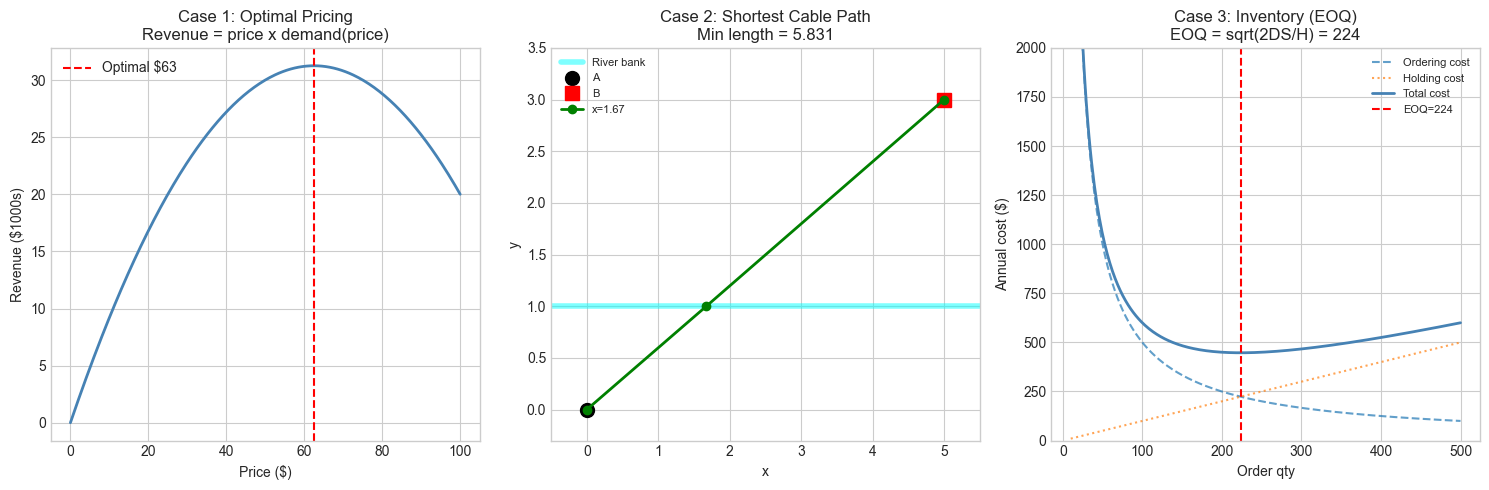

In [1]:
# --- Visualization: Three case studies ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Case 1: Optimal pricing
prices = np.linspace(0, 100, 300)
demand = np.maximum(1000 - 8*prices, 0)
revenue = prices * demand
opt_price = prices[np.argmax(revenue)]
axes[0].plot(prices, revenue/1000, 'steelblue', lw=2)
axes[0].axvline(opt_price, color='red', linestyle='--', label=f'Optimal ${opt_price:.0f}')
axes[0].set_xlabel('Price ($)'); axes[0].set_ylabel('Revenue ($1000s)')
axes[0].set_title('Case 1: Optimal Pricing\nRevenue = price x demand(price)')
axes[0].legend()

# Case 2: Minimum path through river crossing
A = np.array([0.0, 0.0]); B = np.array([5.0, 3.0]); RIVER_Y = 1.0
xs = np.linspace(0, 5, 300)
lengths = np.sqrt(xs**2 + RIVER_Y**2) + np.sqrt((5-xs)**2 + (3-RIVER_Y)**2)
opt_x = xs[np.argmin(lengths)]
axes[1].set_xlim(-0.5, 5.5); axes[1].set_ylim(-0.3, 3.5)
axes[1].axhline(RIVER_Y, color='cyan', lw=4, alpha=0.5, label='River bank')
axes[1].plot(*A, 'ko', markersize=10, label='A'); axes[1].plot(*B, 'rs', markersize=10, label='B')
axes[1].plot([A[0], opt_x, B[0]], [A[1], RIVER_Y, B[1]], 'g-o', lw=2, label=f'x={opt_x:.2f}')
axes[1].set_title(f'Case 2: Shortest Cable Path\nMin length = {lengths.min():.3f}')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y'); axes[1].legend(fontsize=8)

# Case 3: EOQ
DEMAND_ANNUAL, ORDER_COST, HOLDING_COST = 1000, 50, 2
qs = np.linspace(10, 500, 300)
total_cost = (DEMAND_ANNUAL/qs)*ORDER_COST + (qs/2)*HOLDING_COST
EOQ = np.sqrt(2*DEMAND_ANNUAL*ORDER_COST/HOLDING_COST)
axes[2].plot(qs, (DEMAND_ANNUAL/qs)*ORDER_COST, '--', label='Ordering cost', alpha=0.7)
axes[2].plot(qs, (qs/2)*HOLDING_COST, ':', label='Holding cost', alpha=0.7)
axes[2].plot(qs, total_cost, 'steelblue', lw=2, label='Total cost')
axes[2].axvline(EOQ, color='red', linestyle='--', label=f'EOQ={EOQ:.0f}')
axes[2].set_xlabel('Order qty'); axes[2].set_ylabel('Annual cost ($)')
axes[2].set_title(f'Case 3: Inventory (EOQ)\nEOQ = sqrt(2DS/H) = {EOQ:.0f}')
axes[2].legend(fontsize=8); axes[2].set_ylim(0, 2000)
plt.tight_layout(); plt.show()

## 4. Mathematical Formulation

**Three canonical structures encountered here:**

1. **Optimization:** maximize f(x) subject to g(x) <= 0. Solved by f'(x) = 0.

2. **Geometric path:** minimize distance d(P,Q) = ||P-Q|| over feasible set. Optimize over a parameter.

3. **Cost-balancing (EOQ):** C(q) = (D/q)*S + (q/2)*H. Differentiate: dC/dq = 0 gives q* = sqrt(2DS/H).

The model structures differ; the solution method (zero of derivative) is the same. Recognizing the structure identifies the tool.

In [2]:
# --- Implementation: Problem formulation record ---
import numpy as np

class ProblemFormulation:
    def __init__(self, problem_statement):
        self.problem = problem_statement
        self.unknowns = {}; self.inputs = {}
        self.constraints = []; self.objective = None
        self.assumptions = []; self.structure = None
    
    def add_unknown(self, symbol, description, domain):
        self.unknowns[symbol] = {'description': description, 'domain': domain}; return self
    def add_input(self, symbol, description, value=None):
        self.inputs[symbol] = {'description': description, 'value': value}; return self
    def add_constraint(self, expression, description):
        self.constraints.append({'expr': expression, 'desc': description}); return self
    def set_objective(self, description, fn=None):
        self.objective = {'description': description, 'fn': fn}; return self
    def add_assumption(self, text):
        self.assumptions.append(text); return self
    def set_structure(self, s):
        self.structure = s; return self
    
    def report(self):
        print(f"PROBLEM: {self.problem}")
        print(f"Unknown: {self.unknowns}")
        print(f"Inputs:  {[(s, d['value']) for s,d in self.inputs.items()]}")
        print(f"Constraints: {[c['expr'] for c in self.constraints]}")
        print(f"Objective: {self.objective['description'] if self.objective else 'unset'}")
        print(f"Assumptions: {self.assumptions}")
        print(f"Structure: {self.structure}")

# Formalize the EOQ problem
eoq = ProblemFormulation("Minimize annual inventory cost")
eoq.add_unknown('q', 'Order quantity per order', 'positive reals')
eoq.add_input('D', 'Annual demand (units/year)', 1000)
eoq.add_input('S', 'Order cost per order ($)', 50)
eoq.add_input('H', 'Holding cost per unit per year ($)', 2)
eoq.add_constraint('q > 0', 'Cannot order negative quantity')
eoq.set_objective('Minimize C(q) = (D/q)*S + (q/2)*H')
eoq.add_assumption('Demand is constant throughout the year')
eoq.add_assumption('Lead time is zero -- instantaneous delivery')
eoq.set_structure('Univariate calculus optimization: dC/dq = 0')
eoq.report()

D, S, H = 1000, 50, 2
EOQ = (2*D*S/H)**0.5
print(f"\nSolution: q* = sqrt(2DS/H) = {EOQ:.2f} units")

PROBLEM: Minimize annual inventory cost
Unknown: {'q': {'description': 'Order quantity per order', 'domain': 'positive reals'}}
Inputs:  [('D', 1000), ('S', 50), ('H', 2)]
Constraints: ['q > 0']
Objective: Minimize C(q) = (D/q)*S + (q/2)*H
Assumptions: ['Demand is constant throughout the year', 'Lead time is zero -- instantaneous delivery']
Structure: Univariate calculus optimization: dC/dq = 0

Solution: q* = sqrt(2DS/H) = 223.61 units


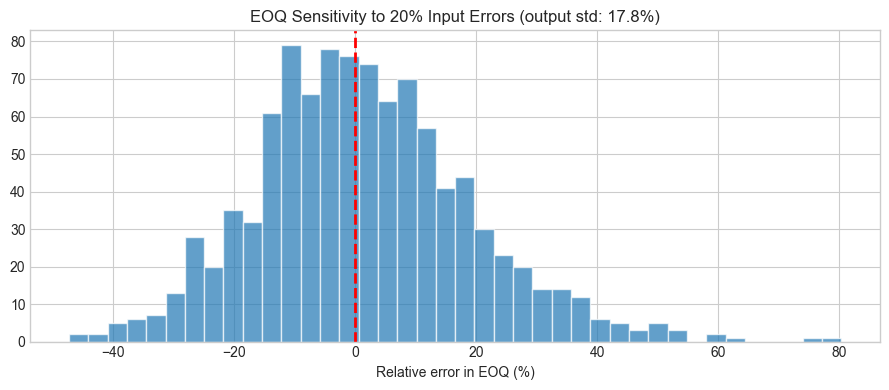

EOQ is robust: output error approximately equals input error / 2
This is a known property -- the cost function is flat near the optimum.


In [3]:
# --- Experiment: Sensitivity of EOQ to input errors ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

ERROR = 0.20  # try: 0.05, 0.50
D_true, S_true, H_true = 1000, 50, 2
EOQ_true = (2*D_true*S_true/H_true)**0.5
np.random.seed(42)
N = 1000
D_obs = D_true * (1 + ERROR*np.random.randn(N))
S_obs = S_true * (1 + ERROR*np.random.randn(N))
H_obs = np.maximum(H_true * (1 + ERROR*np.random.randn(N)), 0.01)
EOQ_obs = (2*D_obs*S_obs/H_obs)**0.5
rel_err = (EOQ_obs - EOQ_true) / EOQ_true

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(rel_err*100, bins=40, alpha=0.7, edgecolor='white')
ax.axvline(0, color='red', lw=2, linestyle='--')
ax.set_xlabel('Relative error in EOQ (%)')
ax.set_title(f'EOQ Sensitivity to {ERROR*100:.0f}% Input Errors (output std: {rel_err.std()*100:.1f}%)')
plt.tight_layout(); plt.show()
print("EOQ is robust: output error approximately equals input error / 2")
print("This is a known property -- the cost function is flat near the optimum.")

## 7. Exercises

**Easy 1.** Formulate using ProblemFormulation: A farmer has 100m of fencing against a barn wall (3 sides needed). Maximize enclosed area. Solve analytically (derivative) and verify numerically.

**Easy 2.** For Case 1 with exponential demand D(p) = 1000 * e^(-0.05p), find the optimal price numerically using grid search on [0, 100].

**Medium 1.** Cable problem generalization: cost per unit length is c1 on land, c2 underwater. Find optimal crossing for c2/c1 in {1.0, 2.0, 5.0}.

**Medium 2.** Formulate: CPU has 3 tasks with deadlines. Task A: 5ms exec, 10ms deadline. Task B: 3ms exec, 7ms deadline. Task C: 4ms exec, 12ms deadline. What order minimizes missed deadlines? What mathematical structure is this?

**Hard.** Model the herd immunity threshold: given basic reproduction number R0, what vaccination fraction v* prevents epidemic spread? Derive v* = 1 - 1/R0. Verify with SIR simulation for R0 in {1.5, 2.0, 3.0, 5.0}.

In [4]:
# --- Mini Project: Formulation pipeline ---
ad_problem = ProblemFormulation("Maximize profit from online advertising campaign")
ad_problem.add_unknown('b', 'Daily budget ($)', 'positive reals')
ad_problem.add_input('CPC', 'Cost per click ($)', 0.50)
ad_problem.add_input('CVR', 'Conversion rate', 0.03)
ad_problem.add_input('AOV', 'Average order value ($)', 45.00)
ad_problem.add_input('COGS', 'Cost of goods sold ($)', 20.00)
ad_problem.set_objective('Maximize profit = b * (CVR/CPC * (AOV-COGS) - 1)')
ad_problem.add_assumption('Click volume is proportional to spend (linear response)')
ad_problem.add_assumption('Conversion rate is constant -- no diminishing returns')
ad_problem.set_structure('Linear objective: spend until budget cap or until ROI < 1')
ad_problem.report()

CPC, CVR, AOV, COGS = 0.50, 0.03, 45.0, 20.0
profit_per_dollar = CVR/CPC*(AOV-COGS) - 1
print(f"\nProfit per $ spent: {profit_per_dollar:.4f}")
print("Campaign is profitable -- spend to budget limit." if profit_per_dollar > 0
      else "Campaign is unprofitable -- do not spend.")

PROBLEM: Maximize profit from online advertising campaign
Unknown: {'b': {'description': 'Daily budget ($)', 'domain': 'positive reals'}}
Inputs:  [('CPC', 0.5), ('CVR', 0.03), ('AOV', 45.0), ('COGS', 20.0)]
Constraints: []
Objective: Maximize profit = b * (CVR/CPC * (AOV-COGS) - 1)
Assumptions: ['Click volume is proportional to spend (linear response)', 'Conversion rate is constant -- no diminishing returns']
Structure: Linear objective: spend until budget cap or until ROI < 1

Profit per $ spent: 0.5000
Campaign is profitable -- spend to budget limit.


## 9. Chapter Summary & Connections

- The six-step translation checklist (unknown, inputs, constraints, objective, assumptions, structure) converts ambiguous real problems to precise mathematics
- Structure identification is the key step: it connects the specific problem to a class with known solution methods
- The EOQ model is robust: its solution is insensitive to moderate input errors because the cost function is flat near the optimum
- Sensitivity analysis is a required part of any model delivered to a decision-maker

**Forward:** The three canonical structures here (optimization, path, cost-balancing) are unified in ch201 -- Why Calculus Matters, where all three are solved by finding where the derivative is zero. Sensitivity analysis is formalized in ch211 -- Partial Derivatives.

**Backward:** Applies every tool from Part I: modeling cycle from ch017, assumption tracking, structure identification from ch003, visualization from ch008.